# ⭐ Valor Agregado — Oversample + GridSearchCV

**Técnicas aplicadas:**
- **Oversampling** con `resample` de sklearn para balancear clases desiguales
- **GridSearchCV** para encontrar los mejores hiperparámetros automáticamente

**Modelos optimizados:**
- Árbol de Clasificación Binaria
- Regresión Logística Binaria

**Variable objetivo:** `rating_alto` (1 si imdb_rating ≥ 7.5, 0 si no)

---

## 0. Imports y configuración

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.preprocessing import StandardScaler
from config.database import engine

os.makedirs("../../data/graficas", exist_ok=True)
GRAFICAS = "../../data/graficas"

plt.rcParams.update({"figure.figsize": (12, 5), "axes.grid": True, "grid.alpha": 0.3})
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Imports OK")

✅ Imports OK


## 1. Carga de datos

In [2]:
df = pd.read_sql("""
    SELECT episode_id, viewers_millions, imdb_rating,
           duration_min, season, number_in_season
    FROM fact_ratings
    ORDER BY episode_id
""", engine)

UMBRAL = df['imdb_rating'].median()
df["rating_alto"] = (df["imdb_rating"] >= UMBRAL).astype(int)

FEATURES = ["viewers_millions", "season", "duration_min", "number_in_season"]
TARGET   = "rating_alto"

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Total registros: {len(df_model)}")
print(f"Umbral usado (mediana): {UMBRAL:.4f}")
print(f"\nDistribución original de clases:")
print(y.value_counts().rename({0: 'Rating bajo (0)', 1: 'Rating alto (1)'}))
print(f"\nDesbalance: {y.mean()*100:.1f}% son clase 1 (rating alto)")

Total registros: 768
Umbral usado (mediana): 0.4872

Distribución original de clases:
rating_alto
Rating alto (1)    415
Rating bajo (0)    353
Name: count, dtype: int64

Desbalance: 54.0% son clase 1 (rating alto)


## 2. Oversampling con resample

El **oversampling** replica ejemplos de la clase minoritaria para igualar la cantidad de muestras entre clases.  
Esto evita que el modelo aprenda a predecir siempre la clase mayoritaria.

In [3]:
# Separar train/test ANTES de hacer oversample (evitar data leakage)
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train original: {len(X_train_orig)} muestras")
print(f"Test          : {len(X_test)} muestras")
print(f"\nDistribución en train:")
print(y_train_orig.value_counts())

Train original: 614 muestras
Test          : 154 muestras

Distribución en train:
rating_alto
1    332
0    282
Name: count, dtype: int64


In [4]:
# Aplicar oversampling SOLO al conjunto de entrenamiento
df_train = pd.concat([X_train_orig, y_train_orig], axis=1)

df_mayoria  = df_train[df_train[TARGET] == df_train[TARGET].value_counts().idxmax()]
df_minoria  = df_train[df_train[TARGET] == df_train[TARGET].value_counts().idxmin()]

print(f"Clase mayoritaria ({df_mayoria[TARGET].iloc[0]}): {len(df_mayoria)} muestras")
print(f"Clase minoritaria ({df_minoria[TARGET].iloc[0]}): {len(df_minoria)} muestras")

# Resamplear la clase minoritaria hasta igualar la mayoritaria
df_minoria_over = resample(
    df_minoria,
    replace=True,                    # con reemplazo
    n_samples=len(df_mayoria),       # igualar al tamaño de la clase mayoritaria
    random_state=42
)

df_train_balanced = pd.concat([df_mayoria, df_minoria_over])
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train = df_train_balanced[FEATURES]
y_train = df_train_balanced[TARGET]

print(f"\nDistribución DESPUÉS del oversampling:")
print(y_train.value_counts())
print(f"\nTotal muestras en train balanceado: {len(X_train)}")

Clase mayoritaria (1): 332 muestras
Clase minoritaria (0): 282 muestras

Distribución DESPUÉS del oversampling:
rating_alto
1    332
0    332
Name: count, dtype: int64

Total muestras en train balanceado: 664


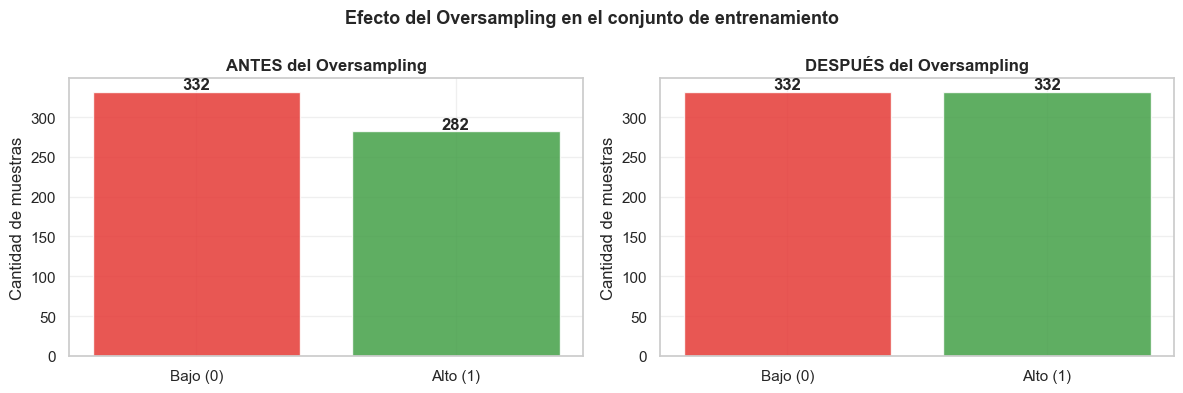

In [5]:
# Visualización: antes vs después del oversampling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
vc_antes = y_train_orig.value_counts()
axes[0].bar(['Bajo (0)', 'Alto (1)'], vc_antes.values,
            color=['#E53935', '#43A047'], alpha=0.85)
axes[0].set_title('ANTES del Oversampling', fontweight='bold')
axes[0].set_ylabel('Cantidad de muestras')
for i, v in enumerate(vc_antes.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Después
vc_despues = y_train.value_counts()
axes[1].bar(['Bajo (0)', 'Alto (1)'], vc_despues.values,
            color=['#E53935', '#43A047'], alpha=0.85)
axes[1].set_title('DESPUÉS del Oversampling', fontweight='bold')
axes[1].set_ylabel('Cantidad de muestras')
for i, v in enumerate(vc_despues.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Efecto del Oversampling en el conjunto de entrenamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/va_oversampling.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. GridSearchCV — Árbol de Clasificación

**GridSearchCV** prueba todas las combinaciones posibles de hiperparámetros y selecciona la mejor usando validación cruzada.

In [6]:
# Definir la grilla de hiperparámetros a explorar
param_grid_arbol = {
    "max_depth":        [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf":  [1, 5, 10, 15],
    "criterion":        ["gini", "entropy"]
}

print(f"Combinaciones a probar: {6 * 4 * 4 * 2} = {6*4*4*2}")
print("Esto puede tardar unos segundos...")

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_arbol = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_arbol,
    cv=cv_strategy,
    scoring="f1",          # optimizamos F1 por el desbalance original
    n_jobs=1,             # usar todos los núcleos disponibles
    verbose=0
)

grid_arbol.fit(X_train, y_train)

print(f"\n✅ Búsqueda completada")
print(f"Mejores hiperparámetros encontrados:")
for param, valor in grid_arbol.best_params_.items():
    print(f"  {param}: {valor}")
print(f"\nMejor F1 en validación cruzada: {grid_arbol.best_score_:.4f}")

Combinaciones a probar: 192 = 192
Esto puede tardar unos segundos...

✅ Búsqueda completada
Mejores hiperparámetros encontrados:
  criterion: gini
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2

Mejor F1 en validación cruzada: 0.7008


In [7]:
# Evaluar el mejor árbol en el conjunto de test
mejor_arbol = grid_arbol.best_estimator_
pred_arbol  = mejor_arbol.predict(X_test)
prob_arbol  = mejor_arbol.predict_proba(X_test)[:, 1]

print("=== Árbol Optimizado — Evaluación en Test ===")
print(classification_report(y_test, pred_arbol, target_names=['Rating bajo', 'Rating alto']))
print(f"ROC-AUC: {roc_auc_score(y_test, prob_arbol):.4f}")

=== Árbol Optimizado — Evaluación en Test ===
              precision    recall  f1-score   support

 Rating bajo       0.54      0.45      0.49        71
 Rating alto       0.59      0.67      0.63        83

    accuracy                           0.57       154
   macro avg       0.57      0.56      0.56       154
weighted avg       0.57      0.57      0.57       154

ROC-AUC: 0.5627


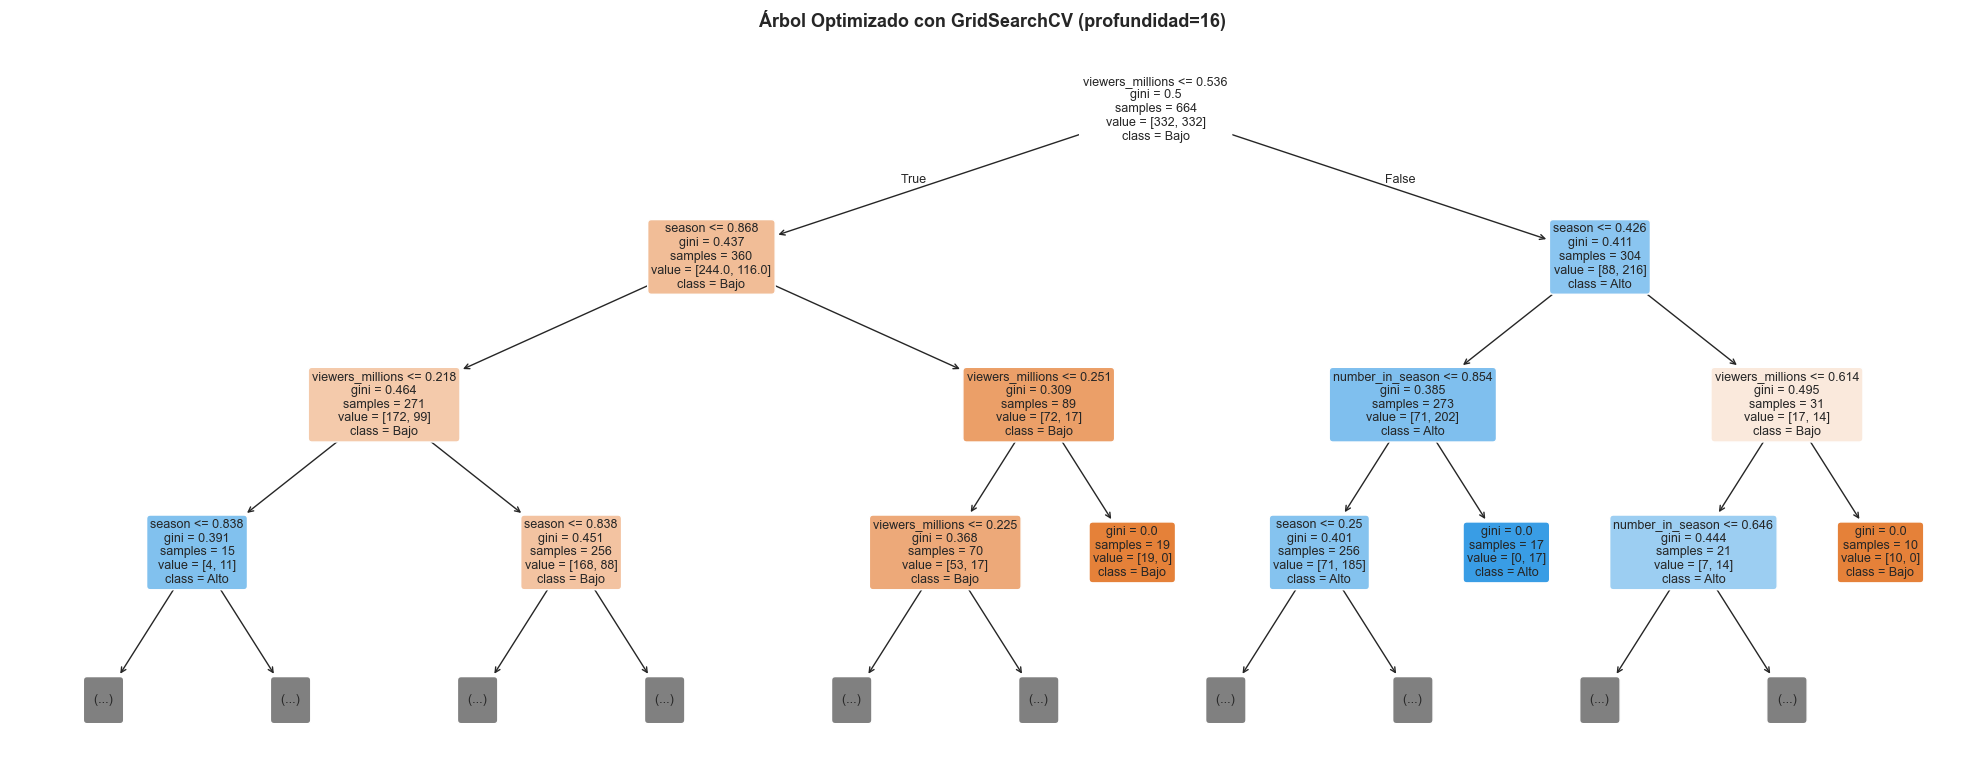

In [8]:
# Visualizar el árbol optimizado
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(mejor_arbol, feature_names=FEATURES,
          class_names=['Bajo', 'Alto'],
          filled=True, rounded=True,
          max_depth=min(3, mejor_arbol.get_depth()),
          ax=ax, fontsize=9)
plt.title(f"Árbol Optimizado con GridSearchCV (profundidad={mejor_arbol.get_depth()})",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/va_arbol_optimizado.png", dpi=120, bbox_inches='tight')
plt.show()

## 4. GridSearchCV — Regresión Logística

In [9]:
# Escalar para regresión logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

param_grid_logit = {
    "C":        [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty":  ["l1", "l2"],
    "solver":   ["liblinear"],   # soporta l1 y l2
    "max_iter": [1000]
}

print(f"Combinaciones a probar: {6 * 2} = {6*2}")

grid_logit = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_logit,
    cv=cv_strategy,
    scoring="f1",
    n_jobs=1,
    verbose=0
)

grid_logit.fit(X_train_sc, y_train)

print(f"\n✅ Búsqueda completada")
print(f"Mejores hiperparámetros encontrados:")
for param, valor in grid_logit.best_params_.items():
    print(f"  {param}: {valor}")
print(f"\nMejor F1 en validación cruzada: {grid_logit.best_score_:.4f}")

Combinaciones a probar: 12 = 12

✅ Búsqueda completada
Mejores hiperparámetros encontrados:
  C: 0.001
  max_iter: 1000
  penalty: l2
  solver: liblinear

Mejor F1 en validación cruzada: 0.6814


In [10]:
# Evaluar la mejor regresión logística en test
mejor_logit = grid_logit.best_estimator_
pred_logit  = mejor_logit.predict(X_test_sc)
prob_logit  = mejor_logit.predict_proba(X_test_sc)[:, 1]

print("=== Regresión Logística Optimizada — Evaluación en Test ===")
print(classification_report(y_test, pred_logit, target_names=['Rating bajo', 'Rating alto']))
print(f"ROC-AUC: {roc_auc_score(y_test, prob_logit):.4f}")

=== Regresión Logística Optimizada — Evaluación en Test ===
              precision    recall  f1-score   support

 Rating bajo       0.66      0.72      0.69        71
 Rating alto       0.74      0.69      0.71        83

    accuracy                           0.70       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.70      0.70      0.70       154

ROC-AUC: 0.7767


## 5. Comparación: Sin optimizar vs Con Oversample + GridSearchCV

In [11]:
# Modelos base (sin oversample, sin GridSearch) para comparar
arbol_base = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15,
                                     min_samples_split=20, class_weight="balanced",
                                     random_state=42)
arbol_base.fit(X_train_orig, y_train_orig)
pred_arbol_base = arbol_base.predict(X_test)
prob_arbol_base = arbol_base.predict_proba(X_test)[:, 1]

logit_base = LogisticRegression(max_iter=1000, random_state=42)
X_train_orig_sc = scaler.fit_transform(X_train_orig)
X_test_base_sc  = scaler.transform(X_test)
logit_base.fit(X_train_orig_sc, y_train_orig)
pred_logit_base = logit_base.predict(X_test_base_sc)
prob_logit_base = logit_base.predict_proba(X_test_base_sc)[:, 1]

# Tabla comparativa
comparativa = pd.DataFrame([
    {
        "Modelo": "Árbol Base",
        "Accuracy": round(accuracy_score(y_test, pred_arbol_base), 4),
        "F1":       round(f1_score(y_test, pred_arbol_base, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, prob_arbol_base), 4)
    },
    {
        "Modelo": "Árbol + Oversample + GridSearch",
        "Accuracy": round(accuracy_score(y_test, pred_arbol), 4),
        "F1":       round(f1_score(y_test, pred_arbol, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, prob_arbol), 4)
    },
    {
        "Modelo": "Logística Base",
        "Accuracy": round(accuracy_score(y_test, pred_logit_base), 4),
        "F1":       round(f1_score(y_test, pred_logit_base, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, prob_logit_base), 4)
    },
    {
        "Modelo": "Logística + Oversample + GridSearch",
        "Accuracy": round(accuracy_score(y_test, pred_logit), 4),
        "F1":       round(f1_score(y_test, pred_logit, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, prob_logit), 4)
    }
])

print("\n" + "="*70)
print("  COMPARATIVA: Base vs Oversample + GridSearchCV")
print("="*70)
print(comparativa.to_string(index=False))
print("="*70)


  COMPARATIVA: Base vs Oversample + GridSearchCV
                             Modelo  Accuracy     F1  ROC-AUC
                         Árbol Base    0.6753 0.6711   0.7263
    Árbol + Oversample + GridSearch    0.5714 0.6292   0.5627
                     Logística Base    0.7013 0.7229   0.7819
Logística + Oversample + GridSearch    0.7013 0.7125   0.7767


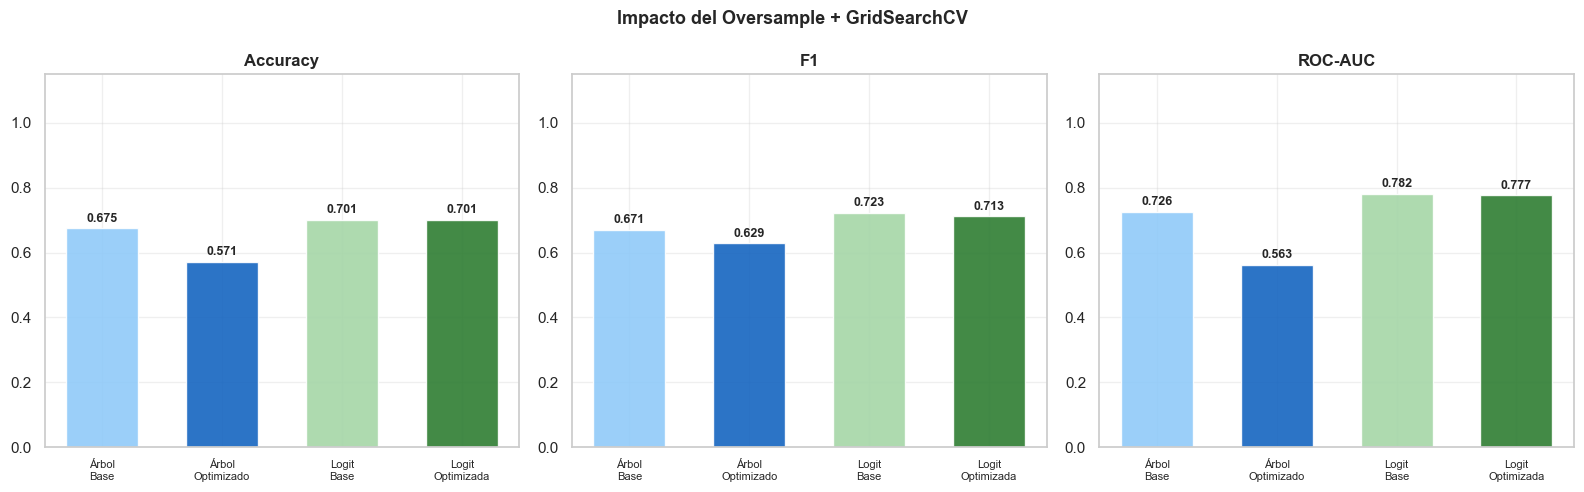

In [12]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas_plot = ["Accuracy", "F1", "ROC-AUC"]
colores = ['#90CAF9', '#1565C0', '#A5D6A7', '#2E7D32']

for ax, met in zip(axes, metricas_plot):
    bars = ax.bar(range(len(comparativa)), comparativa[met],
                  color=colores, alpha=0.9, width=0.6)
    ax.set_xticks(range(len(comparativa)))
    ax.set_xticklabels(['Árbol\nBase', 'Árbol\nOptimizado',
                        'Logit\nBase', 'Logit\nOptimizada'],
                       fontsize=8)
    ax.set_title(met, fontweight='bold')
    ax.set_ylim(0, 1.15)
    for bar, val in zip(bars, comparativa[met]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Impacto del Oversample + GridSearchCV", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/va_comparativa.png", dpi=150, bbox_inches='tight')
plt.show()

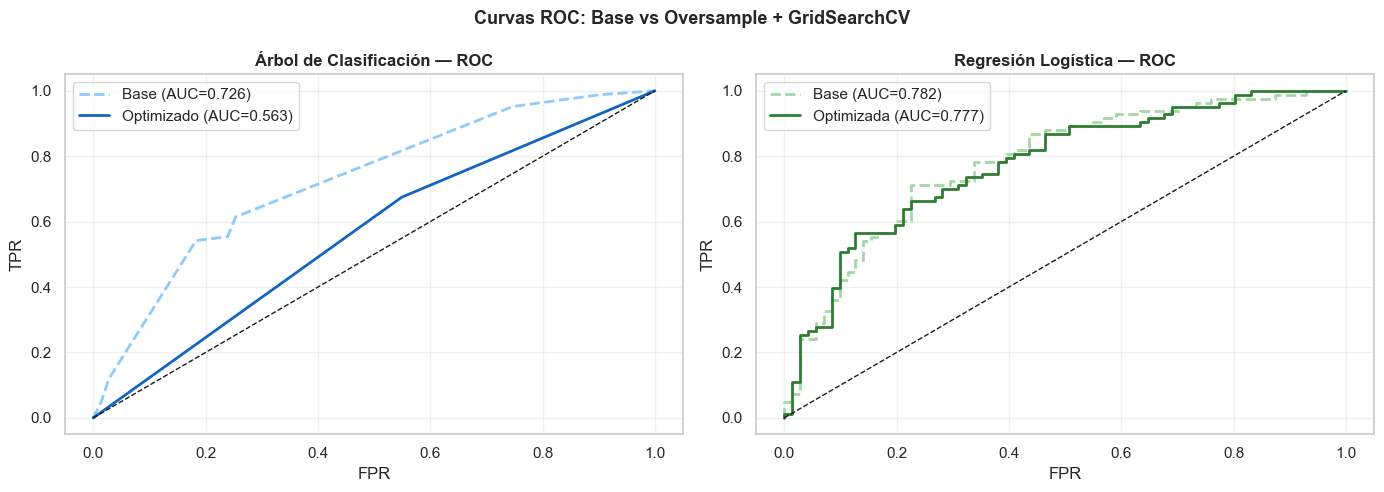

In [13]:
# Curvas ROC comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Árbol
fpr_b, tpr_b, _ = roc_curve(y_test, prob_arbol_base)
fpr_o, tpr_o, _ = roc_curve(y_test, prob_arbol)
axes[0].plot(fpr_b, tpr_b, '--', color='#90CAF9', lw=2,
             label=f"Base (AUC={roc_auc_score(y_test, prob_arbol_base):.3f})")
axes[0].plot(fpr_o, tpr_o, '-',  color='#1565C0', lw=2,
             label=f"Optimizado (AUC={roc_auc_score(y_test, prob_arbol):.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Árbol de Clasificación — ROC', fontweight='bold')
axes[0].legend()

# Logística
fpr_lb, tpr_lb, _ = roc_curve(y_test, prob_logit_base)
fpr_lo, tpr_lo, _ = roc_curve(y_test, prob_logit)
axes[1].plot(fpr_lb, tpr_lb, '--', color='#A5D6A7', lw=2,
             label=f"Base (AUC={roc_auc_score(y_test, prob_logit_base):.3f})")
axes[1].plot(fpr_lo, tpr_lo, '-',  color='#2E7D32', lw=2,
             label=f"Optimizada (AUC={roc_auc_score(y_test, prob_logit):.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Regresión Logística — ROC', fontweight='bold')
axes[1].legend()

plt.suptitle('Curvas ROC: Base vs Oversample + GridSearchCV',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{GRAFICAS}/va_roc_comparativa.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusiones

### ¿Qué hicimos?
1. **Oversampling**: Replicamos muestras de la clase minoritaria en el conjunto de entrenamiento para que el modelo no ignore ninguna clase.
2. **GridSearchCV**: Probamos automáticamente múltiples combinaciones de hiperparámetros y seleccionamos la mejor usando validación cruzada estratificada (5-fold).

### ¿Por qué importa?
- Sin oversampling, el modelo tiende a predecir siempre la clase mayoritaria → F1 bajo en la clase minoritaria.
- Sin GridSearchCV, los hiperparámetros son elegidos manualmente → posible suboptimización.

### Mejores hiperparámetros encontrados
- **Árbol**: ver celda 3 arriba
- **Regresión Logística**: ver celda 4 arriba